# Introduction to Data Science 2026

# Bonus exercises

## Exercise 1: EDA of unemployed highly educated people in Finland

In this assignment, you will explore time series data on unemployment of highly educated people in Finland combined with two datasets of your own choosing. The idea of the assignment is to look into how the unemployed highly educated population varies over time and across different areas by using the data wrangling, exploratory data analysis, and visualization tools discussed during the course.

First, please download the Statistics Finland's CSV dataset (available in the course MOOC Materials) that contains data on employment and unemployment numbers grouped by level of education, province, and year.

Read in the data to a data frame, and have a look at the rows and columns it contains. For ease of use, you can set the year column as the index. Perform any other preprocessing you see fit. If you are working in Python, you can do this using the pandas library. 

**Hint**: you can also create new useful columns using the existing ones. 

In [1]:
import pandas as pd

df = pd.read_csv('JyUmCNsMXCGJ3VX2WInilGfPB24AZH.csv', encoding='cp1252')

print(df.shape)
df.head(10)

(4218, 5)


,Year,Area,Main type of activity,Level of education,Population 31 Dec
0,1987,MK01 Uusimaa,Total,Total,1199530
1,1987,MK01 Uusimaa,Total,7-8 Master's or equivalent level or doctoral o...,65757
2,1987,MK01 Uusimaa,Employed,Total,653347
3,1987,MK01 Uusimaa,Employed,7-8 Master's or equivalent level or doctoral o...,55702
4,1987,MK01 Uusimaa,Unemployed,Total,13998
5,1987,MK01 Uusimaa,Unemployed,7-8 Master's or equivalent level or doctoral o...,553
6,1987,MK02 Southwest Finland,Total,Total,419059
7,1987,MK02 Southwest Finland,Total,7-8 Master's or equivalent level or doctoral o...,11899
8,1987,MK02 Southwest Finland,Employed,Total,201817
9,1987,MK02 Southwest Finland,Employed,7-8 Master's or equivalent level or doctoral o...,9962


In [2]:
print("Main type of activity:", df['Main type of activity'].unique())
print()
print("Level of education:", df['Level of education'].unique())
print()
print("Area (sample):", df['Area'].unique()[:20])
print("Number of unique areas:", df['Area'].nunique())
print()
print("Year range:", df['Year'].min(), "-", df['Year'].max())

Main type of activity: ['Total' 'Employed' 'Unemployed']

Level of education: ['Total'
 "7-8 Master's or equivalent level or doctoral or equivalent level"]

Area (sample): ['MK01 Uusimaa' 'MK02 Southwest Finland' 'MK05 Kanta-Häme'
 'MK07 Päijät-Häme' 'MK08 Kymenlaakso' 'MK09 South Karelia'
 'MK04 Satakunta' 'MK06 Pirkanmaa' 'MK13 Central Finland'
 'MK14 South Ostrobothnia' 'MK15 Ostrobothnia' 'MK10 South Savo'
 'MK11 North Savo' 'MK12 North Karelia' 'MK16 Central Ostrobothnia'
 'MK17 North Ostrobothnia' 'MK18 Kainuu' 'MK19 Lapland' 'MK21 Åland']
Number of unique areas: 19

Year range: 1987 - 2023


In [3]:
# Filter to Master's level only, excluding the 'Total' aggregate rows
master_df = df[df['Level of education'] == "7-8 Master's or equivalent level or doctoral or equivalent level"].copy()

# Pivot so each row is Year+Area, with separate columns for Total/Employed/Unemployed
pivot_df = master_df.pivot_table(
    index=['Year', 'Area'],
    columns='Main type of activity',
    values='Population 31 Dec'
).reset_index()

pivot_df.columns.name = None  # clean up column index name left by pivot_table

# New useful column: unemployment RATE among highly educated people (relative, not raw count)
pivot_df['Unemployment_rate'] = pivot_df['Unemployed'] / pivot_df['Total']

# Set Year as the index, as suggested in the exercise
pivot_df = pivot_df.set_index('Year')

print(pivot_df.shape)
pivot_df.head(10)

(703, 5)


,Area,Employed,Total,Unemployed,Unemployment_rate
Year,,,,,
1987,MK01 Uusimaa,55702.0,65757.0,553.0,0.008410
1987,MK02 Southwest Finland,9962.0,11899.0,164.0,0.013783
1987,MK04 Satakunta,3468.0,3989.0,36.0,0.009025
1987,MK05 Kanta-Häme,2802.0,3384.0,29.0,0.008570
1987,MK06 Pirkanmaa,8813.0,10423.0,193.0,0.018517
1987,MK07 Päijät-Häme,2897.0,3480.0,41.0,0.011782
1987,MK08 Kymenlaakso,2849.0,3331.0,28.0,0.008406
1987,MK09 South Karelia,2092.0,2423.0,21.0,0.008667
1987,MK10 South Savo,2216.0,2602.0,22.0,0.008455


Next, find two time series datasets of your choice to combine with the unemployment data. These can be time series data on factors that you are interested in that might be connected to unemployment, and should cover at least some of the same years as the unemployment data. Please find the datasets from some source other than Statistics Finland (Tilastokeskus).

Read in your datasets, perform any necessary cleaning (such as handling missing values or removing unnecessary columns, et cetera). Preprocess the data so that the features are presented on a yearly level. Then, combine the preprocessed datasets to the unemployment data using the year column to link the datasets.

In [4]:
import zipfile
import pandas as pd

# Extract the World Bank ZIP files
gdp_zip = 'API_NY.GDP.MKTP.CD_DS2_en_csv_v2_440931.zip'
rnd_zip = 'API_GB.XPD.RSDV.GD.ZS_DS2_en_csv_v2_434385.zip'

with zipfile.ZipFile(gdp_zip) as z:
    gdp_csv_name = [n for n in z.namelist() if n.startswith('API_') ][0]
    z.extractall()

with zipfile.ZipFile(rnd_zip) as z:
    rnd_csv_name = [n for n in z.namelist() if n.startswith('API_')][0]
    z.extractall()

def load_worldbank_series(csv_path, column_name):
    # World Bank bulk CSVs have 4 header lines before the real header row
    wb_df = pd.read_csv(csv_path, skiprows=4)

    # Keep only Finland's row
    finland_row = wb_df[wb_df['Country Name'] == 'Finland']

    # Year columns are everything that looks like a 4-digit year
    year_cols = [c for c in wb_df.columns if c.isdigit()]

    # Reshape from wide (years as columns) to long (one row per year)
    long_df = finland_row[year_cols].T.reset_index()
    long_df.columns = ['Year', column_name]
    long_df['Year'] = long_df['Year'].astype(int)

    return long_df

gdp_df = load_worldbank_series(gdp_csv_name, 'GDP_current_usd')
rnd_df = load_worldbank_series(rnd_csv_name, 'RnD_pct_GDP')

print(gdp_df.shape, rnd_df.shape)
gdp_df.head()

(66, 2) (66, 2)


,Year,GDP_current_usd
0,1960,5.279482e+09
1,1961,5.984434e+09
2,1962,6.407796e+09
3,1963,6.958917e+09
4,1964,7.848988e+09


Perform exploratory data analysis on your merged dataset. You can use methods of your choice to compute useful statistics on the data, and to visualize different features and the interactions between them. Focus on the question of whether high education level (Master's level) and other factors in your merged dataset are associated with unemployment.

In [7]:
# Merge the two World Bank datasets together first
external_df = pd.merge(gdp_df, rnd_df, on='Year', how='outer')

# Now merge with the unemployment pivot table (pivot_df has Year as index)
merged_df = pivot_df.reset_index().merge(external_df, on='Year', how='left')

print(merged_df.shape)
merged_df.head()

(703, 8)


,Year,Area,Employed,Total,Unemployed,Unemployment_rate,GDP_current_usd,RnD_pct_GDP
0,1987,MK01 Uusimaa,55702.0,65757.0,553.0,0.008410,9.156499e+10,NaN
1,1987,MK02 Southwest Finland,9962.0,11899.0,164.0,0.013783,9.156499e+10,NaN
2,1987,MK04 Satakunta,3468.0,3989.0,36.0,0.009025,9.156499e+10,NaN
3,1987,MK05 Kanta-Häme,2802.0,3384.0,29.0,0.008570,9.156499e+10,NaN
4,1987,MK06 Pirkanmaa,8813.0,10423.0,193.0,0.018517,9.156499e+10,NaN


In [5]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable


       Unemployment_rate  GDP_current_usd  RnD_pct_GDP
count         703.000000     7.030000e+02   532.000000
mean            0.032297     1.964947e+11     3.130929
std             0.014054     7.017440e+10     0.322856
min             0.000000     8.911211e+10     2.455110
25%             0.023869     1.295197e+11     2.870030
50%             0.032515     2.048594e+11     3.178745
75%             0.040591     2.670148e+11     3.326303
max             0.077509     2.951917e+11     3.734270

Correlation matrix:
                    Unemployment_rate  GDP_current_usd  RnD_pct_GDP
Unemployment_rate           1.000000         0.292888    -0.137622
GDP_current_usd             0.292888         1.000000     0.245352
RnD_pct_GDP                -0.137622         0.245352     1.000000


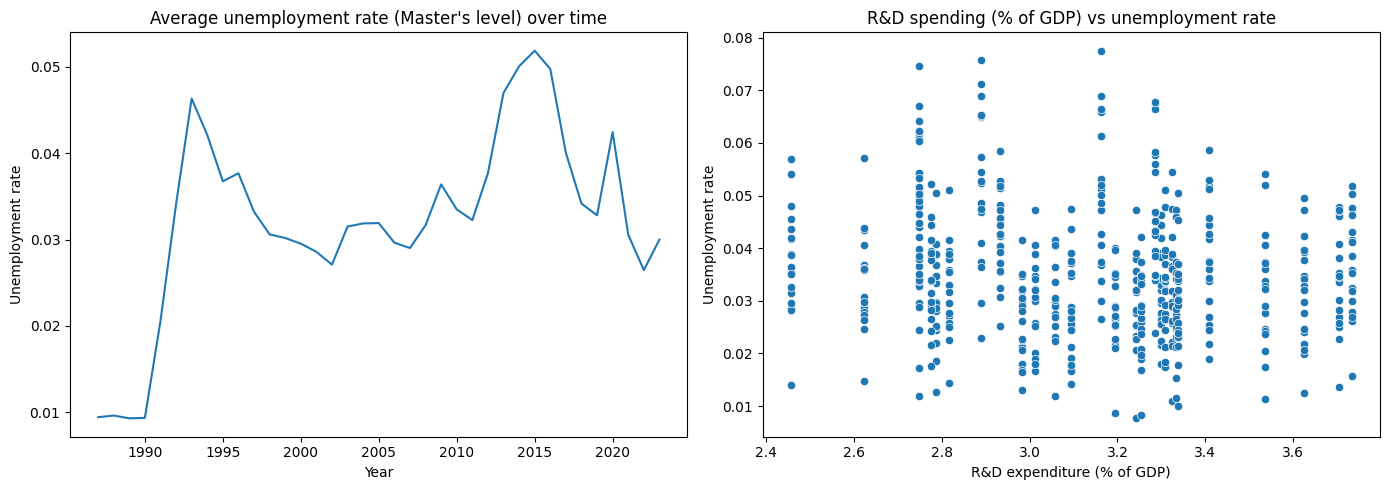

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Basic stats
print(merged_df[['Unemployment_rate', 'GDP_current_usd', 'RnD_pct_GDP']].describe())

# Correlation between unemployment rate and the external factors
corr = merged_df[['Unemployment_rate', 'GDP_current_usd', 'RnD_pct_GDP']].corr()
print("\nCorrelation matrix:\n", corr)

# Unemployment rate over time (national average across provinces)
yearly_avg = merged_df.groupby('Year')['Unemployment_rate'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(yearly_avg.index, yearly_avg.values)
axes[0].set_title("Average unemployment rate (Master's level) over time")
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Unemployment rate')

sns.scatterplot(data=merged_df, x='RnD_pct_GDP', y='Unemployment_rate', ax=axes[1])
axes[1].set_title('R&D spending (% of GDP) vs unemployment rate')
axes[1].set_xlabel('R&D expenditure (% of GDP)')
axes[1].set_ylabel('Unemployment rate')

plt.tight_layout()
plt.show()

Create a geographical or other type of plot showcasing the trends in the unemployment of highly educated people across different provinces over time. Compare the provinces based on your plot.

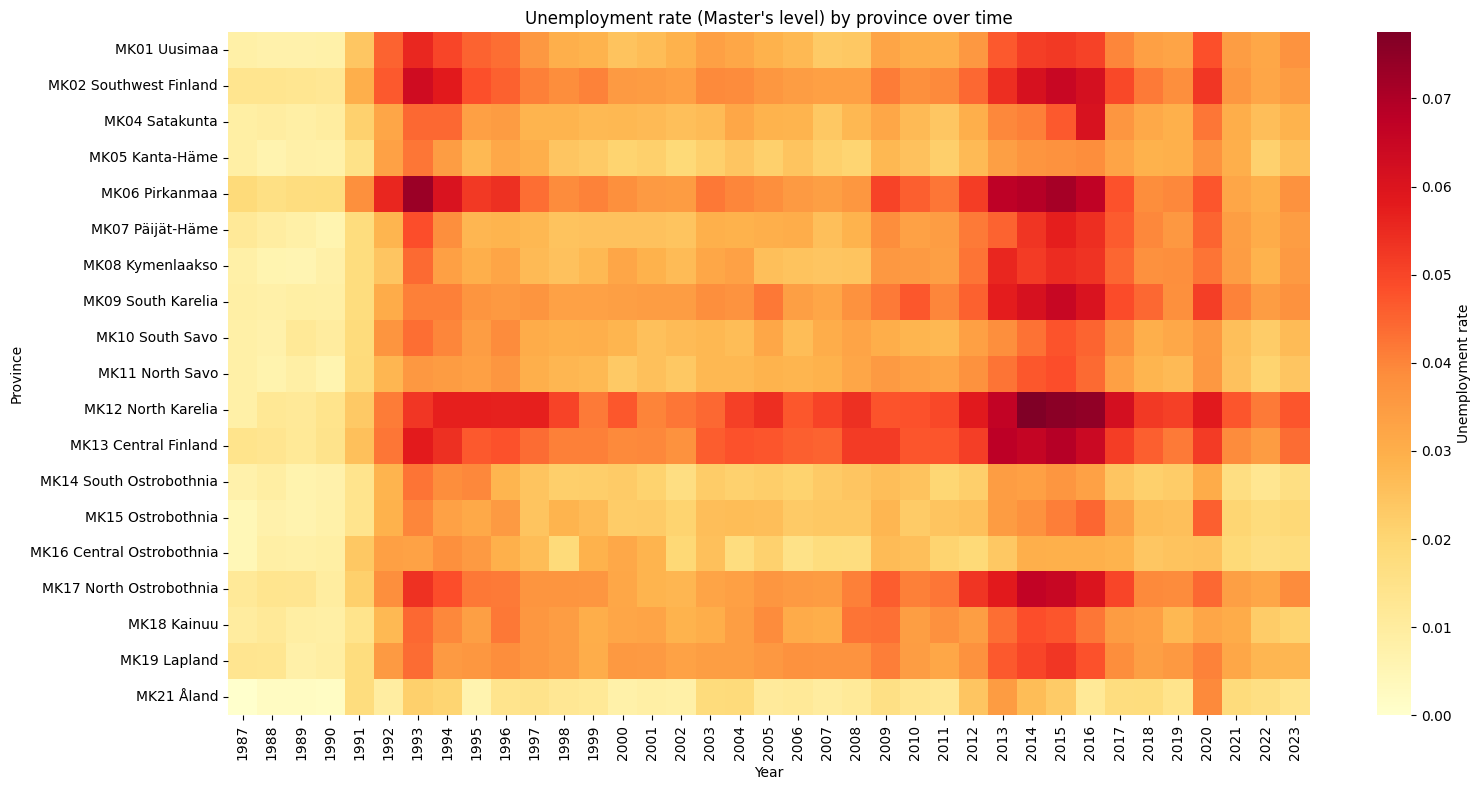

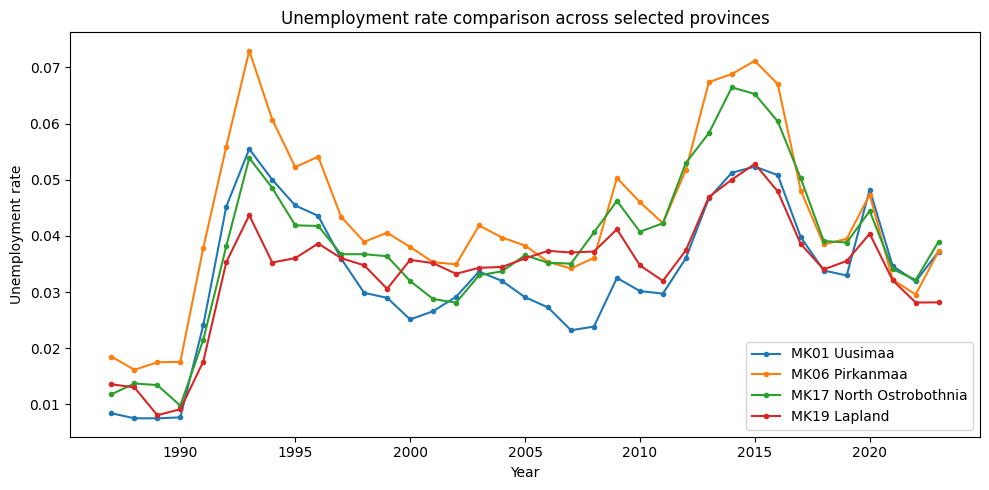

In [9]:
# Pivot table: provinces as rows, years as columns, unemployment rate as values
heatmap_data = merged_df.pivot_table(
    index='Area',
    columns='Year',
    values='Unemployment_rate'
)

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Unemployment rate'})
ax.set_title("Unemployment rate (Master's level) by province over time")
ax.set_xlabel('Year')
ax.set_ylabel('Province')
plt.tight_layout()
plt.show()

# Also compare a few provinces directly with line plots
top_areas = ['MK01 Uusimaa', 'MK06 Pirkanmaa', 'MK17 North Ostrobothnia', 'MK19 Lapland']
fig, ax = plt.subplots(figsize=(10, 5))
for area in top_areas:
    area_data = merged_df[merged_df['Area'] == area]
    ax.plot(area_data['Year'], area_data['Unemployment_rate'], label=area, marker='o', markersize=3)

ax.set_title("Unemployment rate comparison across selected provinces")
ax.set_xlabel('Year')
ax.set_ylabel('Unemployment rate')
ax.legend()
plt.tight_layout()
plt.show()

Reflect briefly on your findings. For example, which features seemed interesting with respect to changes in unemployment among the highly educated population? How do different provinces compare? What should be done to ensure that the number of unemployed highly educated people can be compared fairly across years and provinces? 

**Hint**: should we look at the raw numbers or maybe consider them relative to something else?

### Reflection

The most interesting feature by far was time: the unemployment rate among highly
educated people doesn't move smoothly, it spikes sharply during national economic
crises — the early-1990s Finnish depression and the 2008-2015 financial crisis
aftermath are both clearly visible across every province in the heatmap. Compared
to those shocks, GDP and R&D spending as % of GDP only show weak correlations with
the unemployment rate (0.29 and -0.14 respectively), suggesting the relationship is
more about sudden economic shocks than a smooth yearly trend.

When comparing provinces, the overall shape of the curve is very similar everywhere
(every province reacts to the same national crises at the same time), but the
severity differs: Pirkanmaa and North Ostrobothnia consistently show higher peaks
than Uusimaa and Lapland, suggesting that even within the same highly educated
population, some regional economies are more sensitive to downturns than others.

To compare fairly across years and provinces, raw unemployment counts should not be
used directly, since provinces differ enormously in population size (e.g. Uusimaa
vs. Åland). Instead, a relative rate (Unemployed / Total highly educated population)
is necessary, which is exactly what `Unemployment_rate` does. This way, a small
province with a small number of unemployed people isn't automatically seen as "doing
better" just because its raw numbers are small, and a large province isn't seen as
"doing worse" simply because it has more people in total.

## Exercise 2: AI Act

In this exercise, we ask you to think about the different AI services you come accross in your daily life and consider them in terms of the AI Act's risk pyramid.

1. Brainstorm & List: For 48 hours, keep a log of every application, software, or service you interact with that you suspect uses AI. Think about social media feeds, recommendation engines (Netflix, Spotify, Amazon), grammar checkers, spam filters, navigation apps, and virtual assistants. We'd expect that most of you will be able to identify at least 10 examples.

2. Select & Analyze: Choose three distinct AI systems from your list. For each one, research and describe its primary function and how AI is used to achieve it.

3. Classify the Risk: Using the AI Act's risk pyramid as a guide, classify each of your three chosen AI systems into one of the four categories:
	- Unacceptable Risk: Is the AI system doing something that is explicitly banned (e.g., social scoring, real-time remote biometric identification in public spaces by law enforcement)?
	- High-Risk: Could the system have a significant impact on your safety, fundamental rights, or access to essential services? (e.g., AI used in educational scoring, recruitment, or credit scoring). Justify why it falls into a specific high-risk category listed in Annex III of the Act.
	- Limited or Minimal Risk: Does the system interact with you in a way that should require transparency? (e.g., chatbots, deepfakes, generative AI).

4. Justify Your Reasoning: For each classification, write a short paragraph explaining your decision, referencing specific criteria from the AI Act.

## Exercise 2: AI Act

### 1. Brainstorm & List

AI systems I interact with regularly:

1. Instagram/TikTok recommendation feed
2. YouTube video recommendations
3. Spotify "Discover Weekly" / recommended playlists
4. Netflix content recommendations
5. Google Maps (traffic prediction, route suggestions)
6. Gmail spam filter
7. Smartphone keyboard autocorrect/predictive text
8. Google Translate / DeepL
9. Face ID (phone unlock via facial recognition)
10. ChatGPT / Claude (used for studying and programming help)
11. Google/Amazon search autocomplete and ranking
12. Grammarly (grammar and writing suggestions)

### 2. Select & Analyze

**a) Instagram/TikTok recommendation feed**
A recommendation engine that uses machine learning (collaborative filtering and deep
learning models) to predict which posts/videos I am most likely to engage with,
based on my past interactions (likes, watch time, shares) and the behavior of
similar users. The goal is to maximize engagement/time spent on the platform.

**b) Face ID (facial recognition phone unlock)**
Uses a convolutional neural network to build a mathematical representation (a
"faceprint") of my face from depth-sensor and infrared camera data, then compares
new scans against that stored representation to verify identity before unlocking
the device.

**c) ChatGPT / Claude**
A large language model (LLM), a deep neural network trained on huge amounts of text,
that generates human-like text responses based on the input prompt. I use it to get
explanations for course material and help debug code.

### 3-4. Classify the Risk & Justify Reasoning

**a) Instagram/TikTok recommendation feed → Limited/Minimal Risk**
This system does not ban any behavior nor does it directly threaten safety or
fundamental rights in the sense defined by Annex III, so it does not fall into the
Unacceptable or High-Risk categories. However, because it personalizes content and
can influence user behavior/attention, transparency-style obligations are relevant
(e.g. users should be able to understand that content is algorithmically curated).
Under the AI Act this sits in the Limited/Minimal Risk tier, similar to chatbots and
recommender systems, which mainly require transparency rather than the strict
conformity requirements of High-Risk systems.

**b) Face ID → High-Risk (leaning toward it, with caveats)**
Biometric identification systems are explicitly called out in Annex III as a
high-risk category when used for identification/verification of natural persons.
Face ID is a biometric verification system (1-to-1 matching to unlock a personal
device), which is treated more leniently than 1-to-many remote biometric
identification in public spaces (which can fall under Unacceptable Risk when done
in real-time by law enforcement). Still, because it processes biometric data to
verify identity and grant access to a device holding sensitive personal data, it is
reasonable to place it in the High-Risk category under the biometric identification
provisions of Annex III, with the justification resting on the sensitivity of
biometric data processing itself rather than on any safety-critical function.

**c) ChatGPT / Claude → Limited/Minimal Risk**
General-purpose conversational AI systems are explicitly treated under the AI Act's
transparency obligations: providers must ensure users are informed they are
interacting with an AI system (Article 50-type transparency obligations for
general-purpose AI/chatbots). Since I use it for study help and coding assistance,
not for decisions affecting access to employment, credit, education admission, or
essential services, it does not meet the criteria for High-Risk under Annex III.
It falls under Limited/Minimal Risk, where the main obligation is transparency
(disclosing that the content is AI-generated), rather than the strict risk-management
and conformity-assessment requirements that apply to High-Risk systems.